20:29:41 - cmdstanpy - INFO - Chain [1] start processing
20:29:41 - cmdstanpy - INFO - Chain [1] done processing


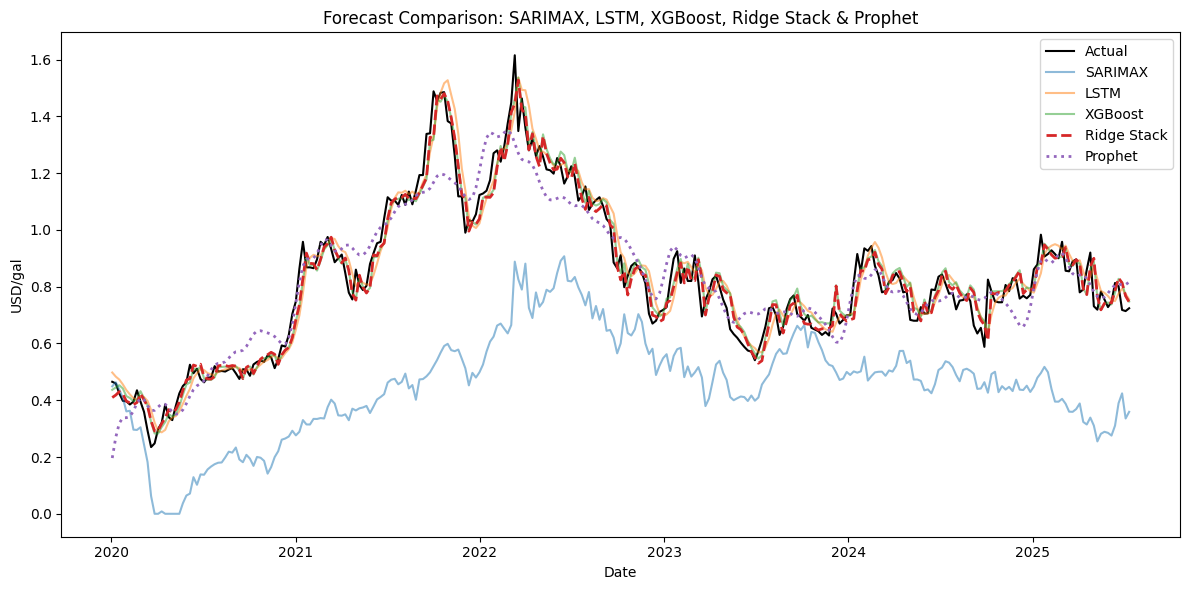

✔️ Combined forecast plot saved: lpg_all_models_forecast_plot.png
In-sample performance:
  sarimax      MAE=0.369, MAPE=44.93%
  lstm         MAE=0.051, MAPE=6.69%
  xgb          MAE=0.044, MAPE=5.65%
  ridge_stack  MAE=0.041, MAPE=5.35%
  prophet      MAE=0.067, MAPE=8.92%
Starting backtesting...
Fold 1:
  sarimax      MAE=0.606, MAPE=59.60%
  lstm         MAE=0.057, MAPE=5.89%
  xgb          MAE=0.046, MAPE=4.72%
  ridge_stack  MAE=0.045, MAPE=4.61%
  prophet      MAE=0.082, MAPE=7.48%

Fold 2:
  sarimax      MAE=0.488, MAPE=41.06%
  lstm         MAE=0.066, MAPE=5.61%
  xgb          MAE=0.054, MAPE=4.60%
  ridge_stack  MAE=0.051, MAPE=4.33%
  prophet      MAE=0.090, MAPE=7.56%

Fold 3:
  sarimax      MAE=0.223, MAPE=29.74%
  lstm         MAE=0.058, MAPE=7.97%
  xgb          MAE=0.047, MAPE=6.41%
  ridge_stack  MAE=0.045, MAPE=6.13%
  prophet      MAE=0.066, MAPE=9.52%

Fold 4:
  sarimax      MAE=0.234, MAPE=29.80%
  lstm         MAE=0.046, MAPE=6.05%
  xgb          MAE=0.042, MAPE=5.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from prophet import Prophet
from sklearn.model_selection import TimeSeriesSplit


root = Path('.')
sarimax = pd.read_csv(root / 'lpg_sarimax_predictions.csv', index_col=0, parse_dates=True).rename(columns={'forecast':'sarimax'})
lstm    = pd.read_csv(root / 'lpg_lstm_predictions.csv',    index_col=0, parse_dates=True).rename(columns={'forecast':'lstm'})
xgb     = pd.read_csv(root / 'lpg_xgboost_predictions.csv', index_col=0, parse_dates=True).rename(columns={'forecast':'xgb'})

df = pd.read_csv(root / 'lpg_dataset.csv', index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last()

df_all = pd.concat([actual, sarimax['sarimax'], lstm['lstm'], xgb['xgb']], axis=1, join='inner').dropna()
df_all = df_all.loc[df_all.index >= '1993-01-01']
df_all.columns = ['actual','sarimax','lstm','xgb']

X_stack = df_all[['sarimax','lstm','xgb']]
y_stack = df_all['actual']
alphas = np.logspace(-3, 3, 13)
stack = RidgeCV(alphas=alphas, store_cv_results=True)
stack.fit(X_stack, y_stack)
df_all['ridge_stack'] = stack.predict(X_stack)
joblib.dump(stack, root / 'lpg_ridge_stack_model.pkl')

df_prophet = df_all[['actual']].reset_index().rename(columns={'index':'ds','actual':'y'})
prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
prophet_model.fit(df_prophet)
prophet_pred = prophet_model.predict(df_prophet[['ds']])
df_all['prophet'] = prophet_pred['yhat'].values
joblib.dump(prophet_model, root / 'lpg_prophet_model.pkl')

for col in ['sarimax','lstm','xgb','ridge_stack','prophet']:
    df_all[[col]].to_csv(root / f'lpg_{col}_predictions.csv')

plt.figure(figsize=(12,6))
plt.plot(df_all.index, df_all['actual'],      label='Actual',      color='k')
plt.plot(df_all.index, df_all['sarimax'],     label='SARIMAX',     alpha=0.5)
plt.plot(df_all.index, df_all['lstm'],        label='LSTM',        alpha=0.5)
plt.plot(df_all.index, df_all['xgb'],         label='XGBoost',     alpha=0.5)
plt.plot(df_all.index, df_all['ridge_stack'], label='Ridge Stack', linestyle='--', linewidth=2)
plt.plot(df_all.index, df_all['prophet'],     label='Prophet',     linestyle=':', linewidth=2)
plt.title('Forecast Comparison: SARIMAX, LSTM, XGBoost, Ridge Stack & Prophet')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.savefig(root / 'lpg_all_models_forecast_plot.png', dpi=300)
plt.show()
print("✔️ Combined forecast plot saved: lpg_all_models_forecast_plot.png")

print("In-sample performance:")
for m in ['sarimax','lstm','xgb','ridge_stack','prophet']:
    mae = mean_absolute_error(df_all['actual'], df_all[m])
    mape = mean_absolute_percentage_error(df_all['actual'], df_all[m]) * 100
    print(f"  {m:<12} MAE={mae:.3f}, MAPE={mape:.2f}%")

# Rolling-origin backtesting
models = ['sarimax','lstm','xgb','ridge_stack','prophet']
results = {m: [] for m in models}
y_vals = df_all['actual'].values
X_preds = {m: df_all[m].values for m in models}
ts_split = TimeSeriesSplit(n_splits=5)
print("Starting backtesting...")
for fold, (train_idx, test_idx) in enumerate(ts_split.split(df_all), start=1):
    print(f"Fold {fold}:")
    y_test = y_vals[test_idx]
    for m in models:
        preds = X_preds[m][test_idx]
        mae_f = mean_absolute_error(y_test, preds)
        mape_f = mean_absolute_percentage_error(y_test, preds) * 100
        results[m].append((mae_f, mape_f))
        print(f"  {m:<12} MAE={mae_f:.3f}, MAPE={mape_f:.2f}%")
    print()

summary = []
for m in models:
    maes, mapes = zip(*results[m])
    summary.append({
        'model': m,
        'mae_mean': np.mean(maes), 'mae_std': np.std(maes),
        'mape_mean': np.mean(mapes), 'mape_std': np.std(mapes)
    })
summary_df = pd.DataFrame(summary)
summary_df.to_csv(root / 'lpg_backtest_summary.csv', index=False)
print("Backtesting summary:")
print(summary_df)
print("✔️ Backtesting complete. Summary saved: lpg_backtest_summary.csv")
